# WISDM Dataset 기반 CNN 분류

### 결과 분석

CNN3 Test accuracy: 94.62%

CNN4 Test accuracy: 96.06%

CNN5 Test accuracy: 91.07%


CNN3, CNN4, CNN5는 각각 test accuracy 94.62%, 96.06%, 91.07%를 기록하였지만 그 중 CNN4가 가장 높은 성능을 보였다.

CNN4가 가장 높은 성능을 보인 이유는 4층 Conv1D로 충분한 표현력을 확보하면서도 MaxPool을 1회만 적용해 시간 정보를 보존했기 때문으로 해석된다.

반면 CNN5는 파라미터가 가장 많음에도 가장 낮은 성능을 보였다.

-> MaxPool을 2회 적용하면서 시퀀스가 50 timestep까지 축소되어 stair 활동의 시간 정보가 과도하게 압축된 것으로 성능 저하가 된 것으로 판단된다.

따라서 단순한 depth 증가가 성능 향상을 보장하지 않는 것을 보여준다.








In [ ]:
# 라이브러리 import
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input, Conv1D, BatchNormalization, ReLU, MaxPool1D,
    GlobalAveragePooling1D, Dense, Dropout
)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.utils import class_weight
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
# 구글 드라이브 연결
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# 경로 정의
DATASET_PATH = "/content/drive/MyDrive/WISDM_ar_v1.1_raw.txt"

## 데이터 전처리

1. **raw 데이터 로드**
2. **클린업** : 마지막 NaN 컬럼 제거, 결측 행 dropna, z_axis의 `;` 제거 후 float 변환
3. **Label Encoding** : LabelEncoder로 activity -> 정수
4. **Data Split (user_id 기반)** :
  - user_id ≤ 26
  - 27 ≤ user_id ≤ 31
  - user_id ≥ 32
5. **정규화** : StandardScaler를 train에서 fit, val/test는 transform만
6. **Segmentation** : sliding window (TIME_STEPS=200, STEP=40)

In [ ]:
# raw 데이터 로드
# WISDM raw data는 컬럼명이 없는 형태
# 각 칼럼에 이름 지정
names = ["user_id", "activity", "timestamp", "x_axis", "y_axis", "z_axis", "NaN"]
data = pd.read_csv(DATASET_PATH, header=None, names=names, comment=";") # 세미콜론 이후 내용 무시
print(data.head())


   user_id activity       timestamp    x_axis     y_axis    z_axis  NaN
0       33  Jogging  49105962326000 -0.694638  12.680544  0.503953  NaN
1       33  Jogging  49106062271000  5.012288  11.264028  0.953424  NaN
2       33  Jogging  49106112167000  4.903325  10.882658 -0.081722  NaN
3       33  Jogging  49106222305000 -0.612916  18.496431  3.023717  NaN
4       33  Jogging  49106332290000 -1.184970  12.108489  7.205164  NaN


In [ ]:
# 클린업
# 문자열 값을 float32 숫자형으로 변환
def convert_to_float(x):
    try:
        return np.float32(x)
    except:
        return np.nan

# 앞에서 raw data를 읽을 때 생긴 불필요한 NaN 컬럼 제거
df = data.drop('NaN', axis=1)
# 결측값 행 제거
df = df.dropna()

# 세미콜론 제거
df["z_axis"] = df["z_axis"].replace(regex=True, to_replace=r';', value=r'')
# x, y, z축 가속도 값을 문자열에서 float32 숫자형으로 변환
df["x_axis"] = df["x_axis"].apply(convert_to_float)
df["y_axis"] = df["y_axis"].apply(convert_to_float)
df["z_axis"] = df["z_axis"].apply(convert_to_float)
df = df.dropna()
df.info()

print("\nActivity counts:")
print(df['activity'].value_counts())


<class 'pandas.core.frame.DataFrame'>
Index: 1098203 entries, 0 to 1098203
Data columns (total 6 columns):
 #   Column     Non-Null Count    Dtype  
---  ------     --------------    -----  
 0   user_id    1098203 non-null  int64  
 1   activity   1098203 non-null  object 
 2   timestamp  1098203 non-null  int64  
 3   x_axis     1098203 non-null  float32
 4   y_axis     1098203 non-null  float32
 5   z_axis     1098203 non-null  float32
dtypes: float32(3), int64(2), object(1)
memory usage: 46.1+ MB

Activity counts:
activity
Walking       424397
Jogging       342176
Upstairs      122869
Downstairs    100427
Sitting        59939
Standing       48395
Name: count, dtype: int64


In [ ]:
# Label Encoding
label_encoder = LabelEncoder()
df['activity_encoded'] = label_encoder.fit_transform(df['activity'])
num_classes = len(label_encoder.classes_)
print("\nLabel mapping:", dict(enumerate(label_encoder.classes_)))



Label mapping: {0: 'Downstairs', 1: 'Jogging', 2: 'Sitting', 3: 'Standing', 4: 'Upstairs', 5: 'Walking'}


In [ ]:
# Data Split (user_id 기반)
# user_id가 26 이하 = train set
df_train = df[df['user_id'] <= 26]
# user_id가 27~31인 = validation set
df_val   = df[(df['user_id'] > 26) & (df['user_id'] < 32)]
# user_id가 32 이상 = test set
df_test  = df[df['user_id'] >= 32]

print(f"\nTrain users: {sorted(df_train['user_id'].unique())}")
print(f"Val   users: {sorted(df_val['user_id'].unique())}")
print(f"Test  users: {sorted(df_test['user_id'].unique())}")



Train users: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26)]
Val   users: [np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31)]
Test  users: [np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36)]


In [ ]:
# 정규화
scaler = StandardScaler()
df_train.loc[:, ['x_axis', 'y_axis', 'z_axis']] = scaler.fit_transform(df_train.loc[:, ['x_axis', 'y_axis', 'z_axis']])
df_val.loc[:,   ['x_axis', 'y_axis', 'z_axis']] = scaler.transform(df_val.loc[:,   ['x_axis', 'y_axis', 'z_axis']])
df_test.loc[:,  ['x_axis', 'y_axis', 'z_axis']] = scaler.transform(df_test.loc[:,  ['x_axis', 'y_axis', 'z_axis']])


In [ ]:
# Segmentation (Sliding Window)
# 연속된 센서 데이터를 고정 길이 window로 분할
def create_dataset(x, y, time_steps=200, step=40):
    xs, ys = [], []
    # 전체 데이터를 time_steps 길이만큼 자르고 step 간격으로 이동
    for i in range(0, len(x) - time_steps, step):
        # 현재 window에 해당하는 x/y/z 센서 값 추출
        v = x.iloc[i:i + time_steps].values
        # 현재 window 안에 포함된 activity label 추출
        labels = y.iloc[i:i + time_steps]
        # window 내부에서 가장 많이 등장한 label을 대표 label로 사용
        values, counts = np.unique(labels, return_counts=True)
        mode_label = values[np.argmax(counts)]
        xs.append(v)
        ys.append(mode_label)
    return np.array(xs), np.array(ys)

TIME_STEPS = 200
STEP = 40
x_train, y_train = create_dataset(df_train[['x_axis', 'y_axis', 'z_axis']], df_train['activity_encoded'], TIME_STEPS, STEP)
x_val,   y_val   = create_dataset(df_val[['x_axis', 'y_axis', 'z_axis']],   df_val['activity_encoded'],   TIME_STEPS, STEP)
x_test,  y_test  = create_dataset(df_test[['x_axis', 'y_axis', 'z_axis']],  df_test['activity_encoded'],  TIME_STEPS, STEP)

print(f"\nx_train: {x_train.shape}, y_train: {y_train.shape}")
print(f"x_val  : {x_val.shape},  y_val  : {y_val.shape}")
print(f"x_test : {x_test.shape},  y_test : {y_test.shape}")


x_train: (19457, 200, 3), y_train: (19457,)
x_val  : (4100, 200, 3),  y_val  : (4100,)
x_test : (3885, 200, 3),  y_test : (3885,)


In [ ]:
# 클래스 가중치 (불균형 보정)
# 모델이 적은 class도 무시하지 않도록 만드는 역할
weights = class_weight.compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights_dict = dict(enumerate(weights))
print("Class weights:", class_weights_dict)

Class weights: {0: np.float64(1.899726615895333), 1: np.float64(0.5175284604745186), 2: np.float64(3.272283888328288), 3: np.float64(4.244546247818499), 4: np.float64(1.4834553217444342), 5: np.float64(0.429912943567988)}


## Model 1
- CNN 3 (Conv1D 3개)

In [ ]:
input_shape = (x_train.shape[1], x_train.shape[2])
num_classes = len(label_encoder.classes_)

model1 = Sequential([
    Input(shape=input_shape),

    Conv1D(64, 5, padding='same'),
    BatchNormalization(),
    ReLU(),

    Conv1D(128, 3, padding='same'),
    BatchNormalization(),
    ReLU(),
    MaxPool1D(),

    Conv1D(256, 3, padding='same'),
    BatchNormalization(),
    ReLU(),

    GlobalAveragePooling1D(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

model1.compile(
    optimizer=Adam(learning_rate=5e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['sparse_categorical_accuracy']
)

print(model1.summary())

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_12 (Conv1D)              │ (None, 200, 64)        │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 200, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_12 (ReLU)                 │ (None, 200, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_13 (Conv1D)              │ (None, 200, 128)       │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 200, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_13 (ReLU)                 │ (None, 200, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_4 (MaxPooling1D)  │ (None, 100, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_14 (Conv1D)              │ (None, 100, 256)       │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 100, 256)       │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_14 (ReLU)                 │ (None, 100, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_3      │ (None, 256)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 193,414 (755.52 KB)

 Trainable params: 192,518 (752.02 KB)

 Non-trainable params: 896 (3.50 KB)

None


In [ ]:
callbacks1 = [
    ModelCheckpoint(
        "WISDM_HAR_CNN3_best.h5",
        save_best_only=True,
        monitor="val_sparse_categorical_accuracy",
        mode='max',
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    ),
    EarlyStopping(
        monitor="val_sparse_categorical_accuracy",
        patience=20,
        verbose=1,
        mode='max',
        restore_best_weights=True
    )
]

history1 = model1.fit(
    x_train, y_train,
    epochs=100,
    batch_size=64,
    validation_data=(x_val, y_val),
    callbacks=callbacks1,
    class_weight=class_weights_dict,
    verbose=1
)

Epoch 1/100
305/305 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.6889 - sparse_categorical_accuracy: 0.7337
Epoch 1: val_sparse_categorical_accuracy improved from None to 0.43707, saving model to WISDM_HAR_CNN3_best.h5



Epoch 1: finished saving model to WISDM_HAR_CNN3_best.h5
305/305 ━━━━━━━━━━━━━━━━━━━━ 11s 20ms/step - loss: 0.4504 - sparse_categorical_accuracy: 0.8351 - val_loss: 1.8307 - val_sparse_categorical_accuracy: 0.4371 - learning_rate: 5.0000e-04
Epoch 2/100
304/305 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.2079 - sparse_categorical_accuracy: 0.9353
Epoch 2: val_sparse_categorical_accuracy improved from 0.43707 to 0.76024, saving model to WISDM_HAR_CNN3_best.h5



Epoch 2: finished saving model to WISDM_HAR_CNN3_best.h5
305/305 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.1811 - sparse_categorical_accuracy: 0.9476 - val_loss: 1.1891 - val_sparse_categorical_accuracy: 0.7602 - learning_rate: 5.0000e-04
Epoch 3/100
305/305 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1305 - sparse_categorical_accuracy: 0.9610
Epoch 3: val_sparse_categorical_accuracy improved from 0.76024 to 0.78463, saving model to WISDM_HAR_CNN3_best.h5



Epoch 3: finished saving model to WISDM_HAR_CNN3_best.h5
305/305 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.1270 - sparse_categorical_accuracy: 0.9638 - val_loss: 1.1554 - val_sparse_categorical_accuracy: 0.7846 - learning_rate: 5.0000e-04
Epoch 4/100
298/305 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1142 - sparse_categorical_accuracy: 0.9644
Epoch 4: val_sparse_categorical_accuracy did not improve from 0.78463
305/305 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.1005 - sparse_categorical_accuracy: 0.9707 - val_loss: 1.5037 - val_sparse_categorical_accuracy: 0.7307 - learning_rate: 5.0000e-04
Epoch 5/100
302/305 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0815 - sparse_categorical_accuracy: 0.9758
Epoch 5: val_sparse_categorical_accuracy did not improve from 0.78463
305/305 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0804 - sparse_categorical_accuracy: 0.9777 - val_loss: 1.7888 - val_sparse_categorical_accuracy: 0.7351 - learning_rate: 5.0000e-04
Epoch 6/100
297/305 ━━━━━━━━━━━━━━━━━━━━ 


Epoch 11: finished saving model to WISDM_HAR_CNN3_best.h5
305/305 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0426 - sparse_categorical_accuracy: 0.9893 - val_loss: 1.1036 - val_sparse_categorical_accuracy: 0.7873 - learning_rate: 2.5000e-04
Epoch 12/100
302/305 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0501 - sparse_categorical_accuracy: 0.9865
Epoch 12: val_sparse_categorical_accuracy did not improve from 0.78732
305/305 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0464 - sparse_categorical_accuracy: 0.9884 - val_loss: 1.7654 - val_sparse_categorical_accuracy: 0.7671 - learning_rate: 2.5000e-04
Epoch 13/100
298/305 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0494 - sparse_categorical_accuracy: 0.9878
Epoch 13: val_sparse_categorical_accuracy did not improve from 0.78732
305/305 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0435 - sparse_categorical_accuracy: 0.9889 - val_loss: 1.3208 - val_sparse_categorical_accuracy: 0.7798 - learning_rate: 2.5000e-04
Epoch 14/100
303/305 ━━━━━━━━━━━━━━━


Epoch 14: finished saving model to WISDM_HAR_CNN3_best.h5
305/305 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0437 - sparse_categorical_accuracy: 0.9889 - val_loss: 1.1489 - val_sparse_categorical_accuracy: 0.7885 - learning_rate: 2.5000e-04
Epoch 15/100
303/305 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0493 - sparse_categorical_accuracy: 0.9883
Epoch 15: val_sparse_categorical_accuracy did not improve from 0.78854

Epoch 15: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
305/305 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0416 - sparse_categorical_accuracy: 0.9896 - val_loss: 1.0512 - val_sparse_categorical_accuracy: 0.7739 - learning_rate: 2.5000e-04
Epoch 16/100
301/305 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0321 - sparse_categorical_accuracy: 0.9916
Epoch 16: val_sparse_categorical_accuracy improved from 0.78854 to 0.80927, saving model to WISDM_HAR_CNN3_best.h5



Epoch 16: finished saving model to WISDM_HAR_CNN3_best.h5
305/305 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0323 - sparse_categorical_accuracy: 0.9915 - val_loss: 1.0147 - val_sparse_categorical_accuracy: 0.8093 - learning_rate: 1.2500e-04
Epoch 17/100
304/305 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0285 - sparse_categorical_accuracy: 0.9926
Epoch 17: val_sparse_categorical_accuracy did not improve from 0.80927
305/305 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0323 - sparse_categorical_accuracy: 0.9916 - val_loss: 1.1613 - val_sparse_categorical_accuracy: 0.7866 - learning_rate: 1.2500e-04
Epoch 18/100
296/305 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0281 - sparse_categorical_accuracy: 0.9934
Epoch 18: val_sparse_categorical_accuracy did not improve from 0.80927
305/305 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0286 - sparse_categorical_accuracy: 0.9935 - val_loss: 1.2171 - val_sparse_categorical_accuracy: 0.7880 - learning_rate: 1.2500e-04
Epoch 19/100
302/305 ━━━━━━━━━━━━━━━


Epoch 25: finished saving model to WISDM_HAR_CNN3_best.h5

Epoch 25: ReduceLROnPlateau reducing learning rate to 3.125000148429535e-05.
305/305 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0218 - sparse_categorical_accuracy: 0.9946 - val_loss: 1.1214 - val_sparse_categorical_accuracy: 0.8098 - learning_rate: 6.2500e-05
Epoch 26/100
295/305 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0179 - sparse_categorical_accuracy: 0.9954
Epoch 26: val_sparse_categorical_accuracy did not improve from 0.80976
305/305 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0198 - sparse_categorical_accuracy: 0.9953 - val_loss: 1.0141 - val_sparse_categorical_accuracy: 0.7966 - learning_rate: 3.1250e-05
Epoch 27/100
305/305 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0174 - sparse_categorical_accuracy: 0.9952
Epoch 27: val_sparse_categorical_accuracy did not improve from 0.80976
305/305 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0188 - sparse_categorical_accuracy: 0.9951 - val_loss: 1.0568 - val_sparse_categorical_acc

In [ ]:
# 모델 평가
model1 = tf.keras.models.load_model("WISDM_HAR_CNN3_best.h5")

train_loss, train_acc = model1.evaluate(x_train, y_train, verbose=0)
print(f"Training accuracy: {train_acc * 100:.2f}%")
print(f"Training loss: {train_loss:.4f}")

test_loss, test_acc = model1.evaluate(x_test, y_test, verbose=0)
print(f"Test accuracy: {test_acc * 100:.2f}%")
print(f"Test loss: {test_loss:.4f}")

Training accuracy: 99.69%
Training loss: 0.0100
Test accuracy: 94.62%
Test loss: 0.2266


In [ ]:
y_pred_proba = model1.predict(x_test, verbose=0)
y_pred = np.argmax(y_pred_proba, axis=1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_, digits=4))


Classification Report:
              precision    recall  f1-score   support

  Downstairs     0.8324    0.8179    0.8251       346
     Jogging     0.9858    0.9498    0.9675      1316
     Sitting     0.9901    0.9967    0.9934       300
    Standing     0.9894    0.9894    0.9894       189
    Upstairs     0.8209    0.9193    0.8673       384
     Walking     0.9617    0.9659    0.9638      1350

    accuracy                         0.9462      3885
   macro avg     0.9300    0.9398    0.9344      3885
weighted avg     0.9480    0.9462    0.9467      3885



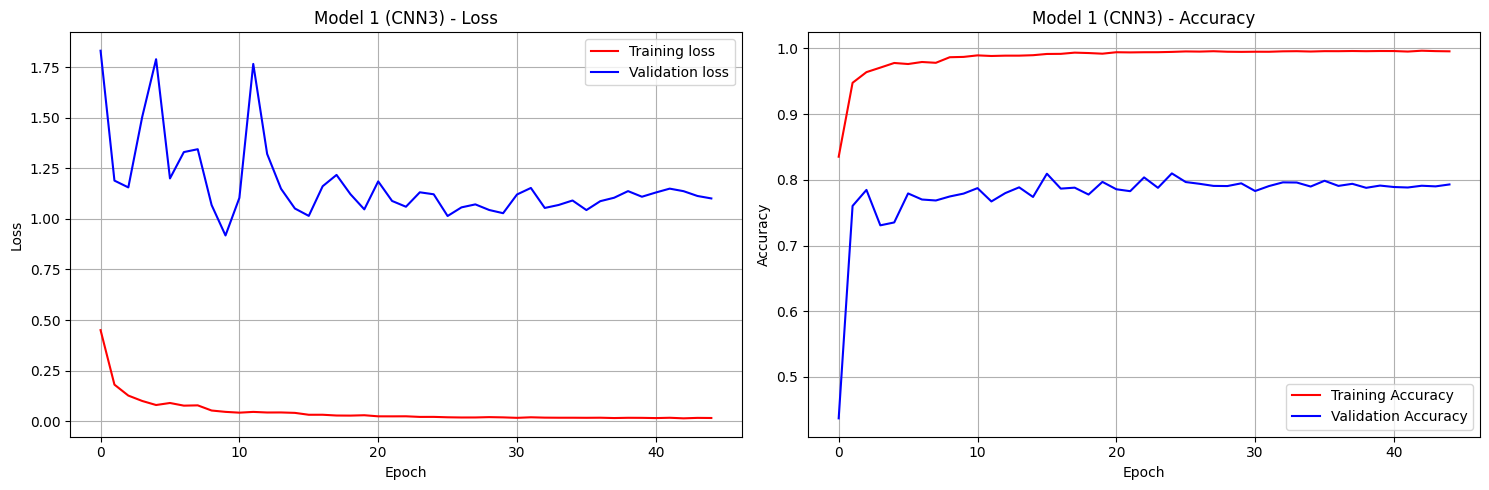

In [ ]:
train_loss = history1.history['loss']
train_accuracy = history1.history['sparse_categorical_accuracy']
val_loss = history1.history['val_loss']
val_accuracy = history1.history['val_sparse_categorical_accuracy']

plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(train_loss, 'r', label='Training loss')
plt.plot(val_loss, 'b', label='Validation loss')
plt.title('Model 1 (CNN3) - Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(train_accuracy, 'r', label='Training Accuracy')
plt.plot(val_accuracy, 'b', label='Validation Accuracy')
plt.title('Model 1 (CNN3) - Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

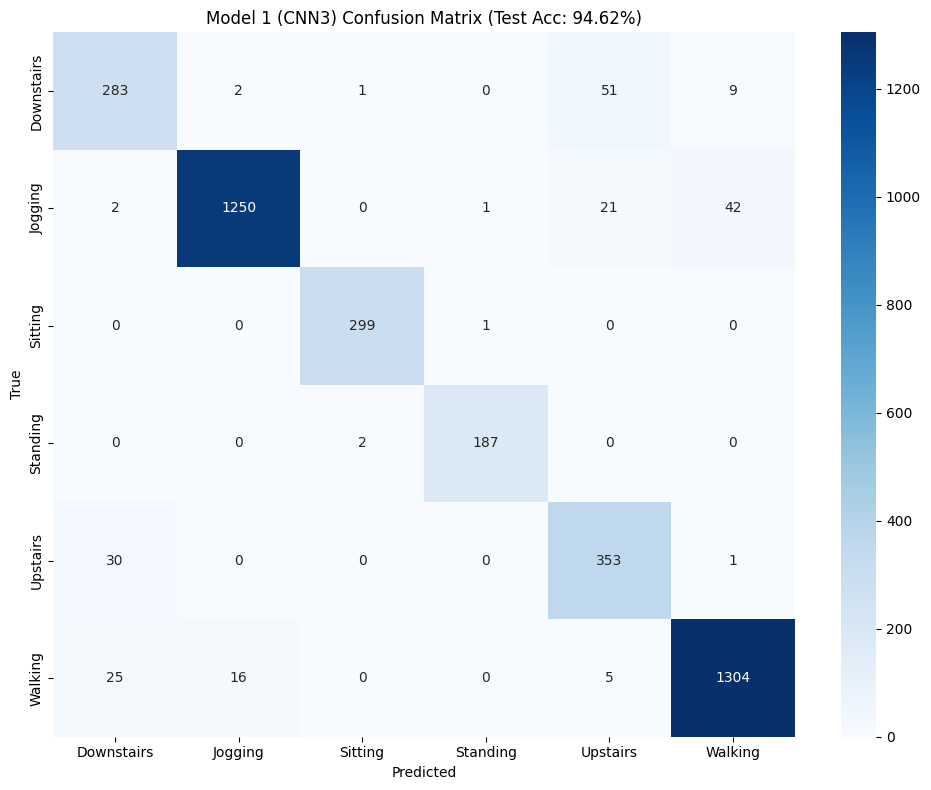

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title(f'Model 1 (CNN3) Confusion Matrix (Test Acc: {test_acc * 100:.2f}%)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

## Model 2
- CNN 4 (Conv1D 4개)

In [ ]:
model2 = Sequential([
    Input(shape=input_shape),

    Conv1D(64, 5, padding='same'),
    BatchNormalization(),
    ReLU(),

    Conv1D(128, 3, padding='same'),
    BatchNormalization(),
    ReLU(),
    MaxPool1D(),

    Conv1D(256, 3, padding='same'),
    BatchNormalization(),
    ReLU(),

    Conv1D(512, 3, padding='same'),
    BatchNormalization(),
    ReLU(),

    GlobalAveragePooling1D(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

model2.compile(
    optimizer=Adam(learning_rate=5e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['sparse_categorical_accuracy']
)

print(model2.summary())

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_15 (Conv1D)              │ (None, 200, 64)        │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 200, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_15 (ReLU)                 │ (None, 200, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_16 (Conv1D)              │ (None, 200, 128)       │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 200, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_16 (ReLU)                 │ (None, 200, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_5 (MaxPooling1D)  │ (None, 100, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_17 (Conv1D)              │ (None, 100, 256)       │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 100, 256)       │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_17 (ReLU)                 │ (None, 100, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_18 (Conv1D)              │ (None, 100, 512)       │       393,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 100, 512)       │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_18 (ReLU)                 │ (None, 100, 512)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_4      │ (None, 512)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 654,726 (2.50 MB)

 Trainable params: 652,806 (2.49 MB)

 Non-trainable params: 1,920 (7.50 KB)

None


In [ ]:
callbacks2 = [
    ModelCheckpoint(
        "WISDM_HAR_CNN4_best.h5",
        save_best_only=True,
        monitor="val_sparse_categorical_accuracy",
        mode='max',
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    ),
    EarlyStopping(
        monitor="val_sparse_categorical_accuracy",
        patience=20,
        verbose=1,
        mode='max',
        restore_best_weights=True
    )
]

history2 = model2.fit(
    x_train, y_train,
    epochs=100,
    batch_size=64,
    validation_data=(x_val, y_val),
    callbacks=callbacks2,
    class_weight=class_weights_dict,
    verbose=1
)

Epoch 1/100
305/305 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.5458 - sparse_categorical_accuracy: 0.7851
Epoch 1: val_sparse_categorical_accuracy improved from None to 0.34902, saving model to WISDM_HAR_CNN4_best.h5



Epoch 1: finished saving model to WISDM_HAR_CNN4_best.h5
305/305 ━━━━━━━━━━━━━━━━━━━━ 15s 28ms/step - loss: 0.3352 - sparse_categorical_accuracy: 0.8787 - val_loss: 2.0449 - val_sparse_categorical_accuracy: 0.3490 - learning_rate: 5.0000e-04
Epoch 2/100
300/305 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1477 - sparse_categorical_accuracy: 0.9615
Epoch 2: val_sparse_categorical_accuracy improved from 0.34902 to 0.75146, saving model to WISDM_HAR_CNN4_best.h5



Epoch 2: finished saving model to WISDM_HAR_CNN4_best.h5
305/305 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 0.1256 - sparse_categorical_accuracy: 0.9663 - val_loss: 1.2056 - val_sparse_categorical_accuracy: 0.7515 - learning_rate: 5.0000e-04
Epoch 3/100
303/305 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1059 - sparse_categorical_accuracy: 0.9710
Epoch 3: val_sparse_categorical_accuracy improved from 0.75146 to 0.77732, saving model to WISDM_HAR_CNN4_best.h5



Epoch 3: finished saving model to WISDM_HAR_CNN4_best.h5
305/305 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 0.0952 - sparse_categorical_accuracy: 0.9750 - val_loss: 1.3197 - val_sparse_categorical_accuracy: 0.7773 - learning_rate: 5.0000e-04
Epoch 4/100
300/305 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0786 - sparse_categorical_accuracy: 0.9786
Epoch 4: val_sparse_categorical_accuracy did not improve from 0.77732
305/305 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 0.0807 - sparse_categorical_accuracy: 0.9793 - val_loss: 1.0623 - val_sparse_categorical_accuracy: 0.7768 - learning_rate: 5.0000e-04
Epoch 5/100
300/305 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0946 - sparse_categorical_accuracy: 0.9719
Epoch 5: val_sparse_categorical_accuracy improved from 0.77732 to 0.82488, saving model to WISDM_HAR_CNN4_best.h5



Epoch 5: finished saving model to WISDM_HAR_CNN4_best.h5
305/305 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 0.0837 - sparse_categorical_accuracy: 0.9769 - val_loss: 0.7216 - val_sparse_categorical_accuracy: 0.8249 - learning_rate: 5.0000e-04
Epoch 6/100
302/305 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0669 - sparse_categorical_accuracy: 0.9813
Epoch 6: val_sparse_categorical_accuracy did not improve from 0.82488
305/305 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 0.0644 - sparse_categorical_accuracy: 0.9830 - val_loss: 1.2260 - val_sparse_categorical_accuracy: 0.7900 - learning_rate: 5.0000e-04
Epoch 7/100
302/305 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0887 - sparse_categorical_accuracy: 0.9741
Epoch 7: val_sparse_categorical_accuracy did not improve from 0.82488
305/305 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 0.0798 - sparse_categorical_accuracy: 0.9785 - val_loss: 1.2488 - val_sparse_categorical_accuracy: 0.7878 - learning_rate: 5.0000e-04
Epoch 8/100
302/305 ━━━━━━━━━━━━━━━━


Epoch 11: finished saving model to WISDM_HAR_CNN4_best.h5
305/305 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 0.0359 - sparse_categorical_accuracy: 0.9914 - val_loss: 0.7165 - val_sparse_categorical_accuracy: 0.8310 - learning_rate: 2.5000e-04
Epoch 12/100
304/305 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0327 - sparse_categorical_accuracy: 0.9910
Epoch 12: val_sparse_categorical_accuracy improved from 0.83098 to 0.89366, saving model to WISDM_HAR_CNN4_best.h5



Epoch 12: finished saving model to WISDM_HAR_CNN4_best.h5
305/305 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 0.0331 - sparse_categorical_accuracy: 0.9914 - val_loss: 0.6456 - val_sparse_categorical_accuracy: 0.8937 - learning_rate: 2.5000e-04
Epoch 13/100
303/305 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0349 - sparse_categorical_accuracy: 0.9926
Epoch 13: val_sparse_categorical_accuracy did not improve from 0.89366
305/305 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.0340 - sparse_categorical_accuracy: 0.9922 - val_loss: 0.8904 - val_sparse_categorical_accuracy: 0.8576 - learning_rate: 2.5000e-04
Epoch 14/100
301/305 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0377 - sparse_categorical_accuracy: 0.9895
Epoch 14: val_sparse_categorical_accuracy did not improve from 0.89366
305/305 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0366 - sparse_categorical_accuracy: 0.9900 - val_loss: 1.3254 - val_sparse_categorical_accuracy: 0.7976 - learning_rate: 2.5000e-04
Epoch 15/100
304/305 ━━━━━━━━━━

In [ ]:
# 모델 평가
model2 = tf.keras.models.load_model("WISDM_HAR_CNN4_best.h5")

train_loss, train_acc = model2.evaluate(x_train, y_train, verbose=0)
print(f"Training accuracy: {train_acc * 100:.2f}%")
print(f"Training loss: {train_loss:.4f}")

test_loss, test_acc = model2.evaluate(x_test, y_test, verbose=0)
print(f"Test accuracy: {test_acc * 100:.2f}%")
print(f"Test loss: {test_loss:.4f}")

Training accuracy: 99.41%
Training loss: 0.0168
Test accuracy: 96.06%
Test loss: 0.2149


In [ ]:
y_pred_proba = model2.predict(x_test, verbose=0)
y_pred = np.argmax(y_pred_proba, axis=1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_, digits=4))


Classification Report:
              precision    recall  f1-score   support

  Downstairs     0.9272    0.8468    0.8852       346
     Jogging     0.9852    0.9590    0.9719      1316
     Sitting     0.9933    0.9933    0.9933       300
    Standing     0.9947    0.9947    0.9947       189
    Upstairs     0.8651    0.9349    0.8986       384
     Walking     0.9624    0.9867    0.9744      1350

    accuracy                         0.9606      3885
   macro avg     0.9547    0.9526    0.9530      3885
weighted avg     0.9613    0.9606    0.9606      3885



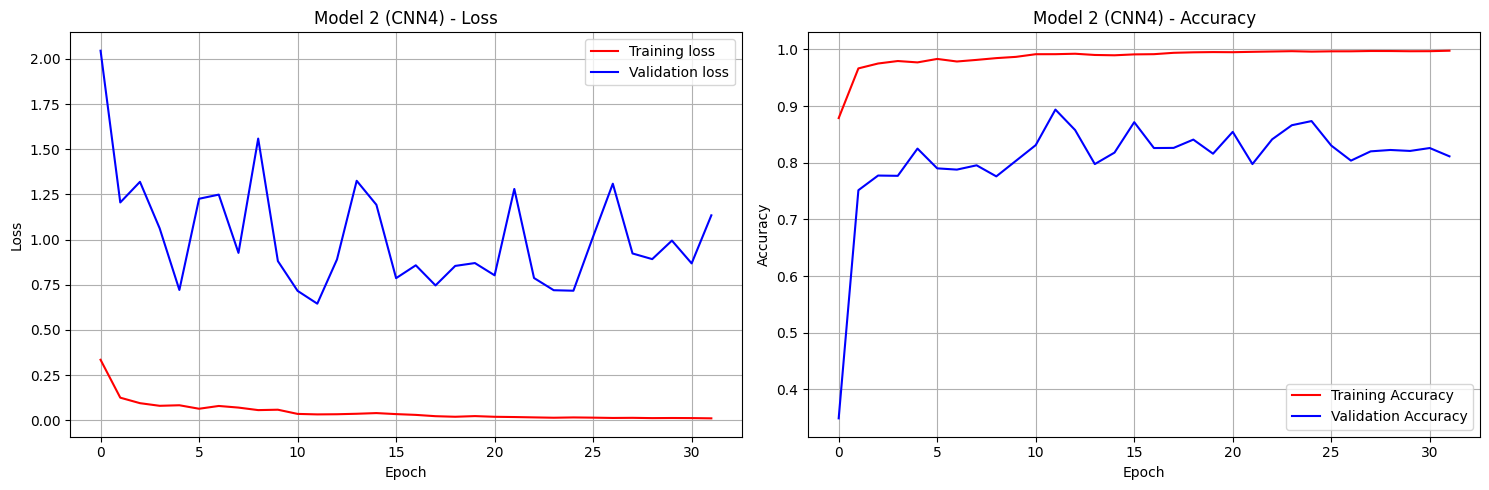

In [ ]:
train_loss = history2.history['loss']
train_accuracy = history2.history['sparse_categorical_accuracy']
val_loss = history2.history['val_loss']
val_accuracy = history2.history['val_sparse_categorical_accuracy']

plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(train_loss, 'r', label='Training loss')
plt.plot(val_loss, 'b', label='Validation loss')
plt.title('Model 2 (CNN4) - Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(train_accuracy, 'r', label='Training Accuracy')
plt.plot(val_accuracy, 'b', label='Validation Accuracy')
plt.title('Model 2 (CNN4) - Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

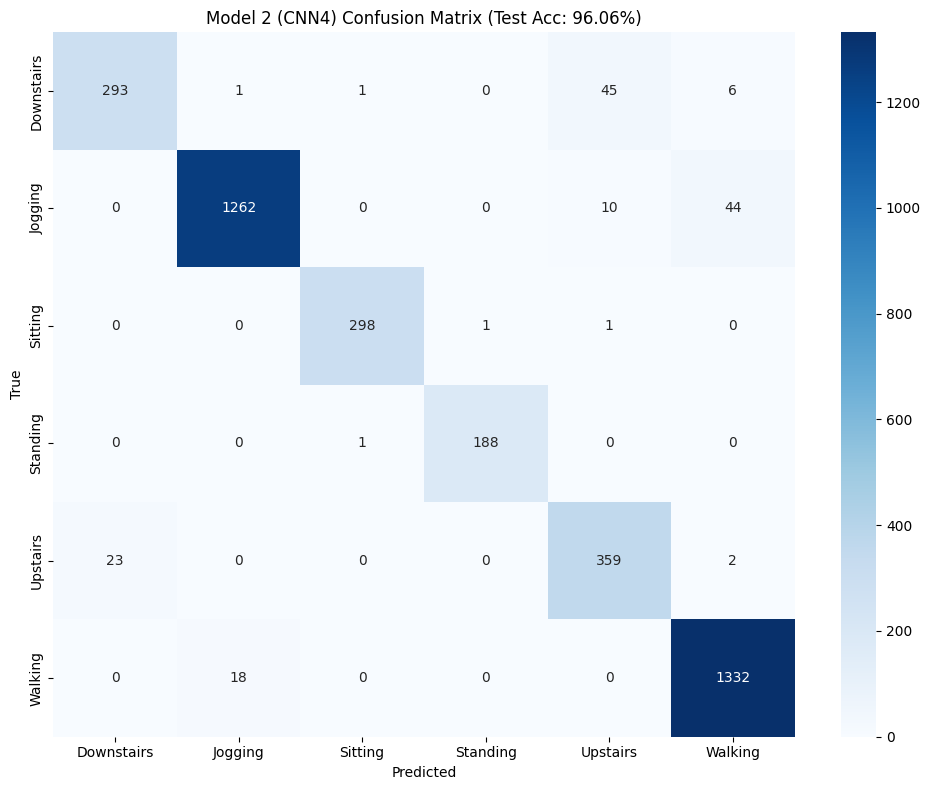

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title(f'Model 2 (CNN4) Confusion Matrix (Test Acc: {test_acc * 100:.2f}%)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

## Model 3
- CNN 5 (Conv1D 5개)

In [ ]:
model3 = Sequential([
    Input(shape=input_shape),

    Conv1D(64, 5, padding='same'),
    BatchNormalization(),
    ReLU(),

    Conv1D(128, 3, padding='same'),
    BatchNormalization(),
    ReLU(),
    MaxPool1D(),

    Conv1D(192, 3, padding='same'),
    BatchNormalization(),
    ReLU(),

    Conv1D(256, 3, padding='same'),
    BatchNormalization(),
    ReLU(),
    MaxPool1D(),

    Conv1D(512, 3, padding='same'),
    BatchNormalization(),
    ReLU(),

    GlobalAveragePooling1D(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

model3.compile(
    optimizer=Adam(learning_rate=5e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['sparse_categorical_accuracy']
)

print(model3.summary())

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_19 (Conv1D)              │ (None, 200, 64)        │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 200, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_19 (ReLU)                 │ (None, 200, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_20 (Conv1D)              │ (None, 200, 128)       │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 200, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_20 (ReLU)                 │ (None, 200, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_6 (MaxPooling1D)  │ (None, 100, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_21 (Conv1D)              │ (None, 100, 192)       │        73,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 100, 192)       │           768 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_21 (ReLU)                 │ (None, 100, 192)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_22 (Conv1D)              │ (None, 100, 256)       │       147,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 100, 256)       │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_22 (ReLU)                 │ (None, 100, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_7 (MaxPooling1D)  │ (None, 50, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_23 (Conv1D)              │ (None, 50, 512)        │       393,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 50, 512)        │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_23 (ReLU)                 │ (None, 50, 512)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_5      │ (None, 512)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 778,566 (2.97 MB)

 Trainable params: 776,262 (2.96 MB)

 Non-trainable params: 2,304 (9.00 KB)

None


In [ ]:
callbacks3 = [
    ModelCheckpoint(
        "WISDM_HAR_CNN5_best.h5",
        save_best_only=True,
        monitor="val_sparse_categorical_accuracy",
        mode='max',
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    ),
    EarlyStopping(
        monitor="val_sparse_categorical_accuracy",
        patience=20,
        verbose=1,
        mode='max',
        restore_best_weights=True
    )
]

history3 = model3.fit(
    x_train, y_train,
    epochs=100,
    batch_size=64,
    validation_data=(x_val, y_val),
    callbacks=callbacks3,
    class_weight=class_weights_dict,
    verbose=1
)

Epoch 1/100
305/305 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.4626 - sparse_categorical_accuracy: 0.8221
Epoch 1: val_sparse_categorical_accuracy improved from None to 0.57122, saving model to WISDM_HAR_CNN5_best.h5



Epoch 1: finished saving model to WISDM_HAR_CNN5_best.h5
305/305 ━━━━━━━━━━━━━━━━━━━━ 17s 27ms/step - loss: 0.2645 - sparse_categorical_accuracy: 0.9102 - val_loss: 1.6635 - val_sparse_categorical_accuracy: 0.5712 - learning_rate: 5.0000e-04
Epoch 2/100
304/305 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1130 - sparse_categorical_accuracy: 0.9643
Epoch 2: val_sparse_categorical_accuracy improved from 0.57122 to 0.76341, saving model to WISDM_HAR_CNN5_best.h5



Epoch 2: finished saving model to WISDM_HAR_CNN5_best.h5
305/305 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 0.0994 - sparse_categorical_accuracy: 0.9717 - val_loss: 1.3357 - val_sparse_categorical_accuracy: 0.7634 - learning_rate: 5.0000e-04
Epoch 3/100
300/305 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0757 - sparse_categorical_accuracy: 0.9800
Epoch 3: val_sparse_categorical_accuracy improved from 0.76341 to 0.80366, saving model to WISDM_HAR_CNN5_best.h5



Epoch 3: finished saving model to WISDM_HAR_CNN5_best.h5
305/305 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0690 - sparse_categorical_accuracy: 0.9816 - val_loss: 1.2984 - val_sparse_categorical_accuracy: 0.8037 - learning_rate: 5.0000e-04
Epoch 4/100
300/305 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0592 - sparse_categorical_accuracy: 0.9850
Epoch 4: val_sparse_categorical_accuracy improved from 0.80366 to 0.83854, saving model to WISDM_HAR_CNN5_best.h5



Epoch 4: finished saving model to WISDM_HAR_CNN5_best.h5
305/305 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 0.0596 - sparse_categorical_accuracy: 0.9852 - val_loss: 0.5974 - val_sparse_categorical_accuracy: 0.8385 - learning_rate: 5.0000e-04
Epoch 5/100
302/305 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0498 - sparse_categorical_accuracy: 0.9877
Epoch 5: val_sparse_categorical_accuracy did not improve from 0.83854
305/305 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 0.0525 - sparse_categorical_accuracy: 0.9871 - val_loss: 0.9602 - val_sparse_categorical_accuracy: 0.8061 - learning_rate: 5.0000e-04
Epoch 6/100
304/305 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0699 - sparse_categorical_accuracy: 0.9806
Epoch 6: val_sparse_categorical_accuracy did not improve from 0.83854
305/305 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 0.0607 - sparse_categorical_accuracy: 0.9839 - val_loss: 1.1076 - val_sparse_categorical_accuracy: 0.7678 - learning_rate: 5.0000e-04
Epoch 7/100
303/305 ━━━━━━━━━━━━━━━━


Epoch 9: finished saving model to WISDM_HAR_CNN5_best.h5

Epoch 9: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
305/305 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - loss: 0.0529 - sparse_categorical_accuracy: 0.9875 - val_loss: 0.7991 - val_sparse_categorical_accuracy: 0.8639 - learning_rate: 5.0000e-04
Epoch 10/100
301/305 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0343 - sparse_categorical_accuracy: 0.9918
Epoch 10: val_sparse_categorical_accuracy did not improve from 0.86390
305/305 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 0.0343 - sparse_categorical_accuracy: 0.9928 - val_loss: 0.6174 - val_sparse_categorical_accuracy: 0.8351 - learning_rate: 2.5000e-04
Epoch 11/100
301/305 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0369 - sparse_categorical_accuracy: 0.9904
Epoch 11: val_sparse_categorical_accuracy did not improve from 0.86390
305/305 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 0.0325 - sparse_categorical_accuracy: 0.9914 - val_loss: 1.1257 - val_sparse_categorical_

In [ ]:
# 모델 평가
model3 = tf.keras.models.load_model("WISDM_HAR_CNN5_best.h5")

train_loss, train_acc = model3.evaluate(x_train, y_train, verbose=0)
print(f"Training accuracy: {train_acc * 100:.2f}%")
print(f"Training loss: {train_loss:.4f}")

test_loss, test_acc = model3.evaluate(x_test, y_test, verbose=0)
print(f"Test accuracy: {test_acc * 100:.2f}%")
print(f"Test loss: {test_loss:.4f}")

Training accuracy: 97.62%
Training loss: 0.0690
Test accuracy: 91.07%
Test loss: 0.4048


In [ ]:
y_pred_proba = model3.predict(x_test, verbose=0)
y_pred = np.argmax(y_pred_proba, axis=1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_, digits=4))


Classification Report:
              precision    recall  f1-score   support

  Downstairs     0.8902    0.6561    0.7554       346
     Jogging     0.9929    0.9590    0.9756      1316
     Sitting     1.0000    0.9933    0.9967       300
    Standing     0.7373    0.9947    0.8468       189
    Upstairs     0.9046    0.5677    0.6976       384
     Walking     0.8594    0.9963    0.9228      1350

    accuracy                         0.9107      3885
   macro avg     0.8974    0.8612    0.8658      3885
weighted avg     0.9168    0.9107    0.9055      3885



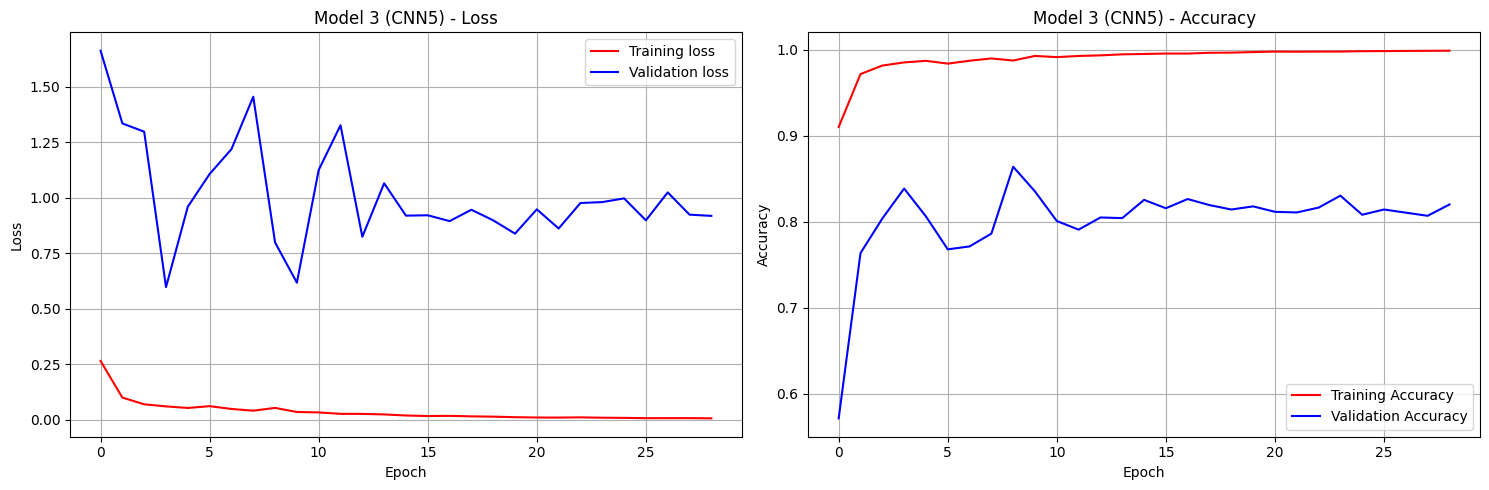

In [ ]:
train_loss = history3.history['loss']
train_accuracy = history3.history['sparse_categorical_accuracy']
val_loss = history3.history['val_loss']
val_accuracy = history3.history['val_sparse_categorical_accuracy']

plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(train_loss, 'r', label='Training loss')
plt.plot(val_loss, 'b', label='Validation loss')
plt.title('Model 3 (CNN5) - Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(train_accuracy, 'r', label='Training Accuracy')
plt.plot(val_accuracy, 'b', label='Validation Accuracy')
plt.title('Model 3 (CNN5) - Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

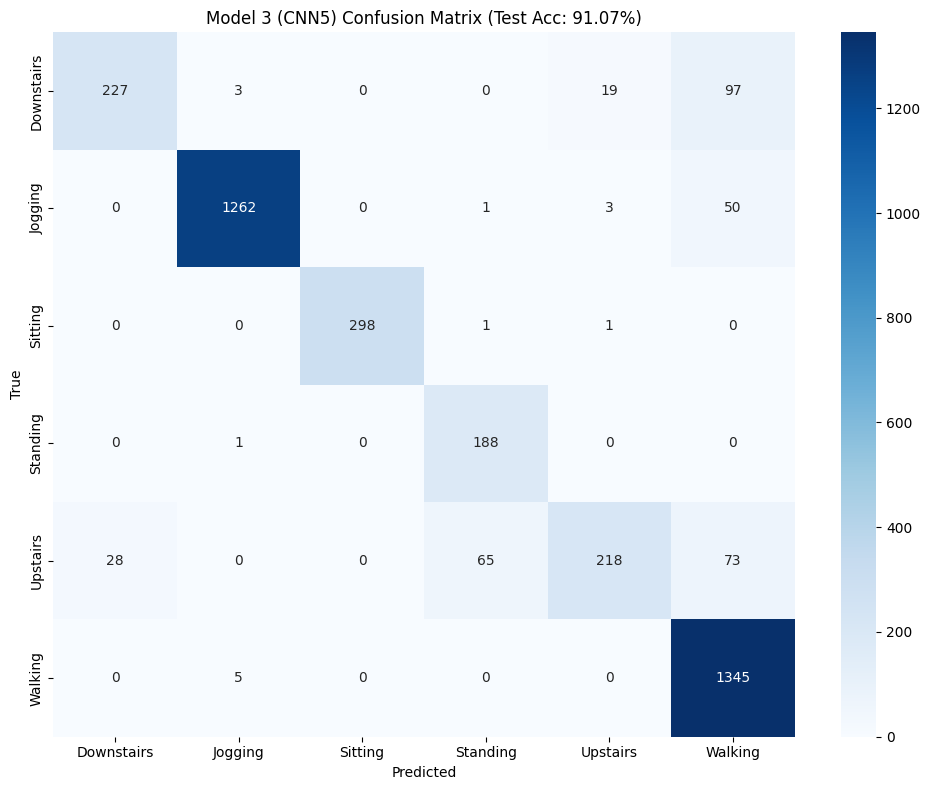

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title(f'Model 3 (CNN5) Confusion Matrix (Test Acc: {test_acc * 100:.2f}%)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

Downstairs samples: 2518
Upstairs   samples: 3065


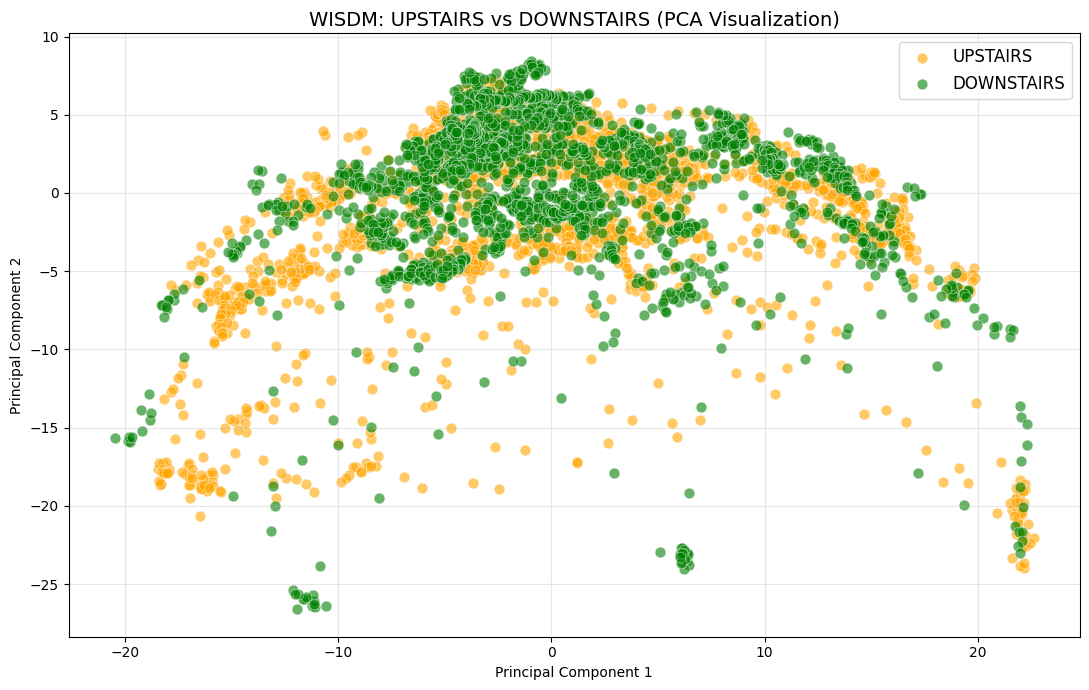


PCA explained variance: PC1=18.23%, PC2=9.02%


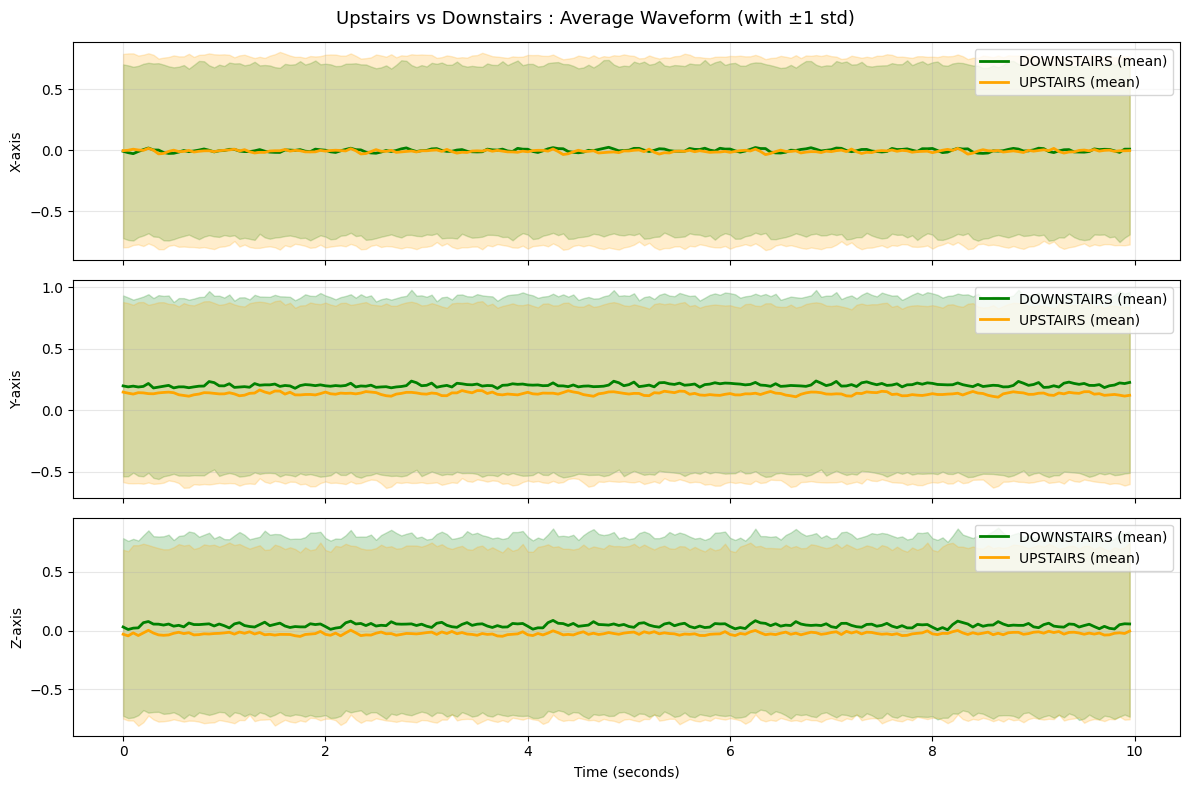

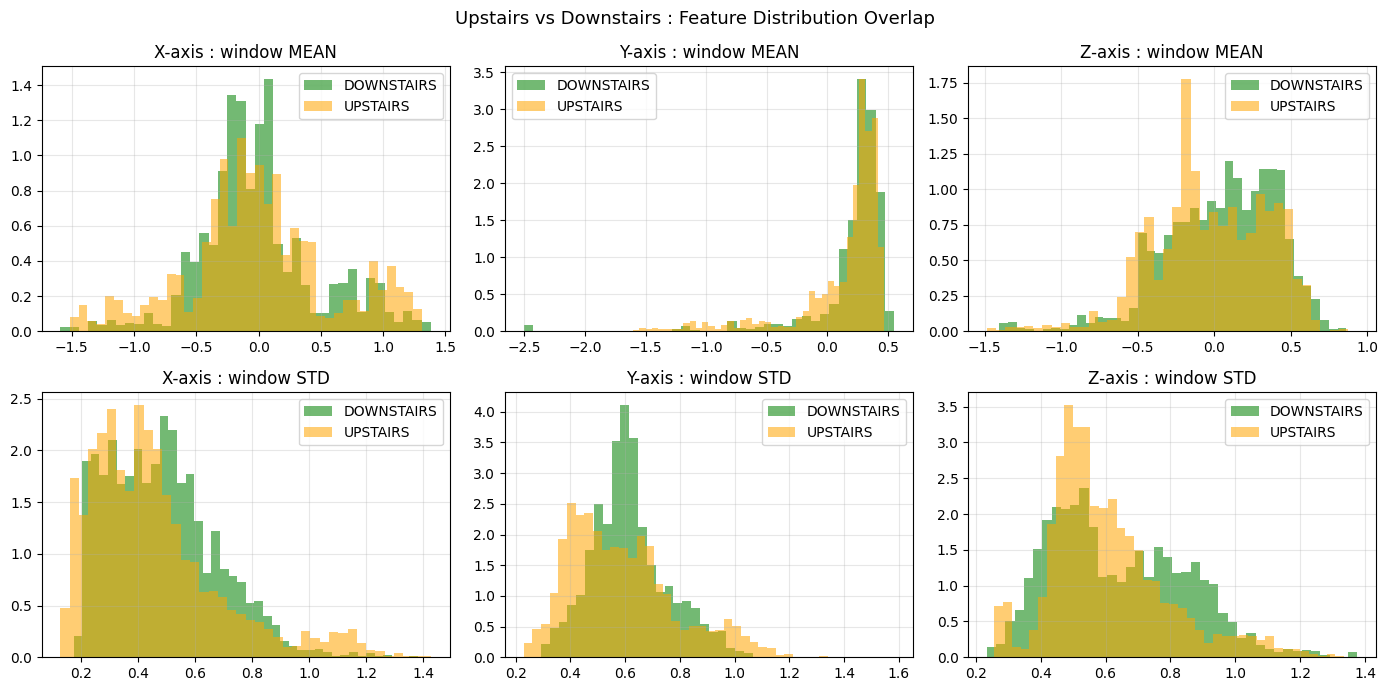

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# 라벨: 0=Downstairs, 4=Upstairs
X_all = np.concatenate([x_train, x_val, x_test], axis=0)
y_all = np.concatenate([y_train, y_val, y_test], axis=0)

X_down = X_all[y_all == 0]  # Downstairs
X_up   = X_all[y_all == 4]  # Upstairs

print(f"Downstairs samples: {len(X_down)}")
print(f"Upstairs   samples: {len(X_up)}")

axis_names = ['X', 'Y', 'Z']
t = np.arange(200) / 20  # 20Hz → seconds


# 1. PCA Visualization
X_d_flat = X_down.reshape(len(X_down), -1)
X_u_flat = X_up.reshape(len(X_up),   -1)

X_combined = np.vstack([X_d_flat, X_u_flat])
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_combined)

X_d_pca = X_pca[:len(X_d_flat)]
X_u_pca = X_pca[len(X_d_flat):]

plt.figure(figsize=(11, 7))
plt.scatter(X_u_pca[:, 0], X_u_pca[:, 1],
            c='orange', alpha=0.6, label='UPSTAIRS', s=60,
            edgecolors='white', linewidths=0.5)
plt.scatter(X_d_pca[:, 0], X_d_pca[:, 1],
            c='green', alpha=0.6, label='DOWNSTAIRS', s=60,
            edgecolors='white', linewidths=0.5)
plt.title('WISDM: UPSTAIRS vs DOWNSTAIRS (PCA Visualization)', fontsize=14)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nPCA explained variance: "
      f"PC1={pca.explained_variance_ratio_[0]*100:.2f}%, "
      f"PC2={pca.explained_variance_ratio_[1]*100:.2f}%")


# 2. 평균 파형 비교 (axis별, ±1 std)
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
for i, ax in enumerate(axes):
    down_mean, down_std = X_down[:, :, i].mean(axis=0), X_down[:, :, i].std(axis=0)
    up_mean,   up_std   = X_up[:, :, i].mean(axis=0),   X_up[:, :, i].std(axis=0)

    ax.plot(t, down_mean, 'g-', linewidth=2, label='DOWNSTAIRS (mean)')
    ax.fill_between(t, down_mean - down_std, down_mean + down_std, alpha=0.2, color='green')

    ax.plot(t, up_mean, color='orange', linewidth=2, label='UPSTAIRS (mean)')
    ax.fill_between(t, up_mean - up_std, up_mean + up_std, alpha=0.2, color='orange')

    ax.set_ylabel(f'{axis_names[i]}-axis')
    ax.legend(loc='upper right')
    ax.grid(alpha=0.3)
axes[-1].set_xlabel('Time (seconds)')
plt.suptitle('Upstairs vs Downstairs : Average Waveform (with ±1 std)', fontsize=13)
plt.tight_layout()
plt.show()


# 3. 통계 피처 분포 overlap
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for i in range(3):
    # 윈도우별 평균
    axes[0, i].hist(X_down[:, :, i].mean(axis=1), bins=40, alpha=0.55,
                    color='green',  label='DOWNSTAIRS', density=True)
    axes[0, i].hist(X_up[:, :, i].mean(axis=1),   bins=40, alpha=0.55,
                    color='orange', label='UPSTAIRS',   density=True)
    axes[0, i].set_title(f'{axis_names[i]}-axis : window MEAN')
    axes[0, i].legend(); axes[0, i].grid(alpha=0.3)

    # 윈도우별 표준편차 (보행 강도 차이가 드러나는 피처)
    axes[1, i].hist(X_down[:, :, i].std(axis=1), bins=40, alpha=0.55,
                    color='green',  label='DOWNSTAIRS', density=True)
    axes[1, i].hist(X_up[:, :, i].std(axis=1),   bins=40, alpha=0.55,
                    color='orange', label='UPSTAIRS',   density=True)
    axes[1, i].set_title(f'{axis_names[i]}-axis : window STD')
    axes[1, i].legend(); axes[1, i].grid(alpha=0.3)

plt.suptitle('Upstairs vs Downstairs : Feature Distribution Overlap', fontsize=13)
plt.tight_layout()
plt.show()